In [31]:
import os
import glob
import numpy as np
import pandas as pd
%matplotlib widget
import matplotlib.pyplot as plt
import xspec
from astropy.io import fits

In [32]:
xspec.Xset.abund = "feld"      # Solar abundance standard (Feldman 1992)
xspec.Xset.xsect = "bcmc"      # Cross-sections
xspec.Fit.statMethod = "cstat" # Use Cash statistics for potential low counts
xspec.Fit.nIterations = 50
xspec.Xset.chatter = 0
xspec.Xset.logChatter = 0

In [40]:
spectra_dir = "AL1_SLX_L1_20260621/PI20260621"
pi_files = sorted(glob.glob(os.path.join(spectra_dir, "*.pi")))
hdul = fits.open('AL1_SLX_L1_20260621/AL1_SOLEXS_20260621_SDD2_L1.lc.gz')
lc_data = hdul['RATE'].data
time = np.array(lc_data['TIME'])
lccounts = np.array(lc_data['COUNTS'])
time-=time[0]
time = time[::60]
lccounts = lccounts[::60]

In [34]:
results = []

for i in range(len(pi_files)):
    try:
        # 1. Clear any previous data and load the current 30s PI file
        xspec.AllData.clear()
        spec = xspec.Spectrum(pi_files[i])
            
        # 2. Ignore noisy background channels (SoLEXS range is ~2-22 keV)
        spec.ignore("**-2.8 15.0-**")
            
        # 3. Define the thermal plasma model (vapec)
        # Component 1 parameters: [kT(keV), Abund, Redshift, Norm]
        mdl = xspec.Model("vapec")
            
        # Set a smart initial guess for kT to help convergence
        mdl.vapec.kT.values = 1.0 
            
        # 4. Run the fitting engine
        xspec.Fit.perform()
            
        # 5. Extract best-fit parameters
        kt_val = mdl.vapec.kT.values[0]
        norm_val = mdl.vapec.norm.values[0]
            
        # Append values along with a running physical time axis (Minutes)
        time_min = i * 60
        results.append([time_min, kt_val, norm_val])
        print(i)
    except:
        pass

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [35]:
raw_features = []

print(f"Extracting raw data features from {len(pi_files)} files...")

for i in range(len(pi_files)):
    try:
        # Open the file using astropy to read structural elements directly
        with fits.open(pi_files[i]) as hdul:
            
            # 1. Extract Aperture State from the Primary Header
            # ('APERTURE' or 'SLITSTUS' track the mechanical 10mm² vs 0.1mm² status)
            aperture_state = hdul[0].header.get('APERTURE', 'UNKNOWN')
            time_start = hdul[1].header.get('TSTART', 0.0)
        
            # 2. Access the Spectrum Data table extension
            spec_table = hdul[1].data
            channels = spec_table['CHANNEL']
            counts = spec_table['COUNTS']
            
            # 3. Calculate Total Raw Integrated Counts (The baseline light curve)
            total_raw_counts = np.sum(counts)
            
            # 4. Compute Hardness Ratio (HR) 
            # High Energy (e.g., channels 100-220) / Low Energy (e.g., channels 20-60)
            low_energy_sum = np.sum(counts[(channels >= 20) & (channels <= 60)])
            high_energy_sum = np.sum(counts[(channels >= 100) & (channels <= 220)])
            
            # Safe divide logic to prevent crashing during quiet background slots
            hr_value = high_energy_sum / low_energy_sum if low_energy_sum > 0 else 0.0
            
            # Mirror the running timeline axis from your XSPEC loop
            time_min = i * 60  
            
            raw_features.append([time_min, pi_files[i].split('/')[-1], aperture_state, total_raw_counts, hr_value, time_start])
            
    except Exception as e:
        # Pass silently or log corrupt file names
        pass

# Convert the raw extractions into a structured pandas DataFrame
df2 = pd.DataFrame(raw_features, columns=[
    "Time_Min", "File_Name", "Aperture_State", "Total_Counts", "Hardness_Ratio", "TSTART"
])

print(f"Done! Raw features collected for {len(df_raw)} records.")
df2.head()

Extracting raw data features from 1440 files...
Done! Raw features collected for 1440 records.


,Time_Min,File_Name,Aperture_State,Total_Counts,Hardness_Ratio,TSTART
0,0,AL1_SOLEXS_20260621_SDD2_L1_1782000001_1782000...,UNKNOWN,1264.0,0.000000,2026-06-21T05:30:01
1,60,AL1_SOLEXS_20260621_SDD2_L1_1782000061_1782000...,UNKNOWN,1249.0,0.000000,2026-06-21T05:31:01
2,120,AL1_SOLEXS_20260621_SDD2_L1_1782000121_1782000...,UNKNOWN,1251.0,0.000842,2026-06-21T05:32:01
3,180,AL1_SOLEXS_20260621_SDD2_L1_1782000181_1782000...,UNKNOWN,1275.0,0.001630,2026-06-21T05:33:01
4,240,AL1_SOLEXS_20260621_SDD2_L1_1782000241_1782000...,UNKNOWN,1257.0,0.002545,2026-06-21T05:34:01


In [49]:
df1 = pd.DataFrame(results, columns=["Time_Min", "Temperature_keV", "EM_proxy"])

df1['Counts'] = lccounts

df = pd.merge(df1, df2, on="Time_Min")
df.head()

,Time_Min,Temperature_keV,EM_proxy,Counts,File_Name,Aperture_State,Total_Counts,Hardness_Ratio,TSTART
0,0,0.387982,2.585564e+06,NaN,AL1_SOLEXS_20260621_SDD2_L1_1782000001_1782000...,UNKNOWN,1264.0,0.000000,2026-06-21T05:30:01
1,60,0.407949,1.979647e+06,3.0,AL1_SOLEXS_20260621_SDD2_L1_1782000061_1782000...,UNKNOWN,1249.0,0.000000,2026-06-21T05:31:01
2,120,0.611123,2.619167e+05,6.0,AL1_SOLEXS_20260621_SDD2_L1_1782000121_1782000...,UNKNOWN,1251.0,0.000842,2026-06-21T05:32:01
3,180,0.559777,3.455634e+05,8.0,AL1_SOLEXS_20260621_SDD2_L1_1782000181_1782000...,UNKNOWN,1275.0,0.001630,2026-06-21T05:33:01
4,240,0.832785,1.531296e+05,9.0,AL1_SOLEXS_20260621_SDD2_L1_1782000241_1782000...,UNKNOWN,1257.0,0.002545,2026-06-21T05:34:01


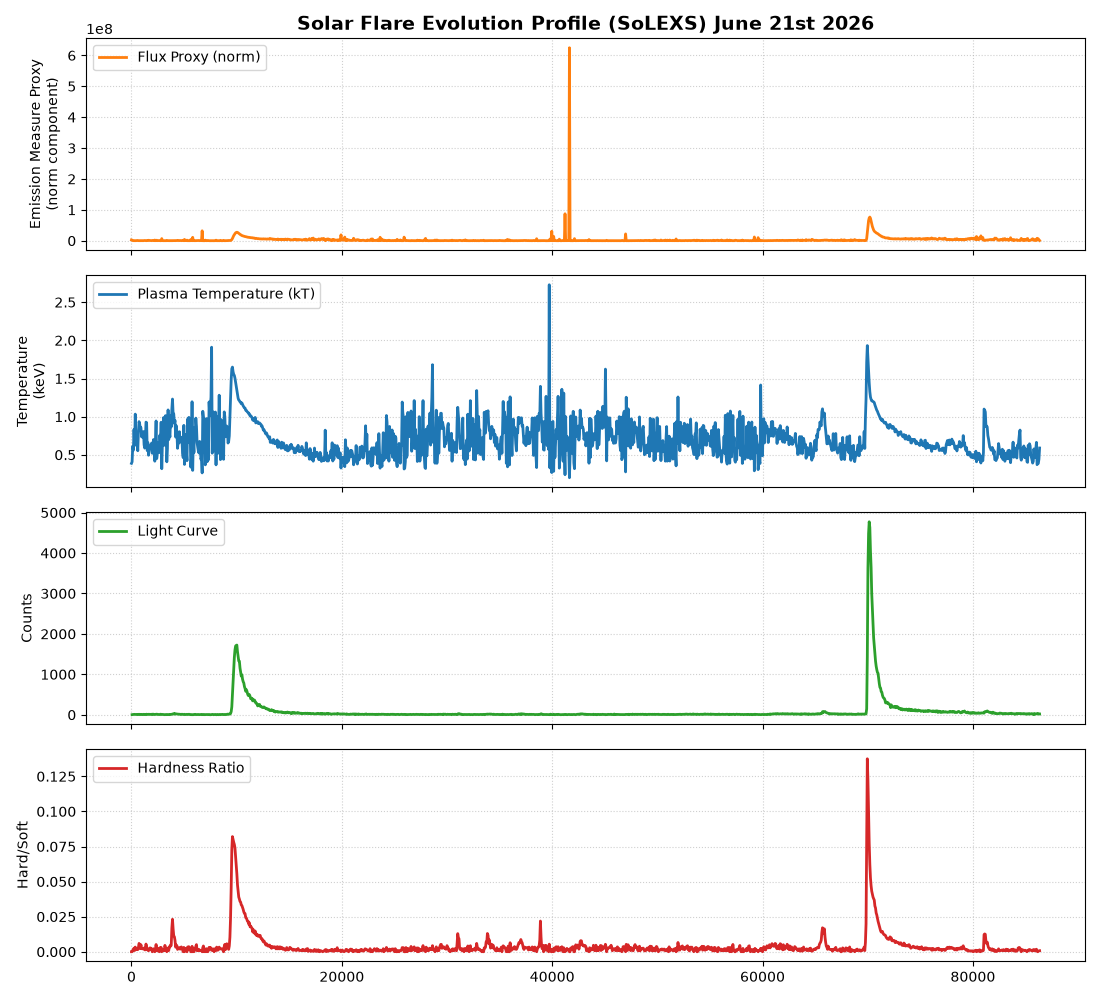

In [50]:
# Create a figure with 3 distinct stacked panels sharing the same X-axis
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(11, 10), sharex=True)

axes[0].set_title('Solar Flare Evolution Profile (SoLEXS) June 21st 2026', fontsize=14, fontweight='bold')
# 1. Top Panel: Flux Proxy (Model Normalization)
# This serves as your Light Curve to identify when the flare spikes occur
axes[0].plot(df['Time_Min'], df['EM_proxy'], color='tab:orange', linewidth=2, label='Flux Proxy (norm)')
axes[0].set_ylabel('Emission Measure Proxy\n(norm component)', fontsize=10)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='upper left')

# 2. Middle Panel: Plasma Temperature (kT)
# Watch for this to peak right before or at the start of the flux spike
axes[1].plot(df['Time_Min'], df['Temperature_keV'], color='tab:blue', linewidth=2, label='Plasma Temperature (kT)')
axes[1].set_ylabel('Temperature\n(keV)', fontsize=10)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc='upper left')

# 3. Light Curve: Brightness curve
axes[2].plot(df['Time_Min'], df['Counts'], color='tab:green', linewidth=2, label="Light Curve")
axes[2].set_ylabel('Counts', fontsize=10)
axes[2].grid(True, linestyle=':', alpha=0.6)
axes[2].legend(loc='upper left')

# 4. Hardness Ratio: Spectral evolution indicator
axes[3].plot(df['Time_Min'], df['Hardness_Ratio'], color='tab:red', linewidth=2, label="Hardness Ratio")
axes[3].set_ylabel('Hard/Soft', fontsize=10)
axes[3].grid(True, linestyle=':', alpha=0.6)
axes[3].legend(loc='upper left')

# Clean up layout adjustments
plt.tight_layout()
plt.show()